In [1]:
import os
import gc
import json
import time
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score,
                             recall_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support)
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import Adam 
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else 
                     ("mps" if torch.backends.mps.is_available() else "cpu"))

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants1 as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *
from Utils.lookahead import Lookahead

In [3]:
print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x104f4f7d0>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x39ef767d0>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x39ef82590>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x3aa2794d0>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
toxic_idx = train_class_to_idx['toxic']

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight,label_smoothing=0.1)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss)
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [14]:
# Calculate balanced class weights based on inverse frequency
class_counts = train['class'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_counts)  # Normalize
class_weights = class_weights.to(device)

print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

criterion = FocalLoss(weight=class_weights, gamma=2.0)

Class counts: [12847 12846 12846]
Class weights: tensor([0.9999, 1.0000, 1.0000], device='mps:0')


## Training and Validation

### Load RESNET50 Model

In [15]:
clear_memory()

In [16]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

In [17]:
base_opt = torch.optim.RAdam([
    {"params": model.conv1.parameters(), "lr": 1e-5},
    {"params": model.bn1.parameters(), "lr": 1e-5},
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 2e-5},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
], weight_decay=0.01)

optimizer = Lookahead(base_opt, k=5, alpha=0.5)

In [18]:
# warmup for 5 epochs, then Cosine Decay
num_epochs = 50

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)

In [19]:
main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs - 5, eta_min=1e-6)

In [20]:
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, main_scheduler], milestones=[5])

In [21]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_robustv1_best.pth"
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
print("Model initialized successfully!")

Model initialized successfully!


In [22]:
def run_one_epoch(model, loader, criterion, optimizer, device, toxic_idx, is_train=False, return_preds=False):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    model.train() if is_train else model.eval()
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(img)
            loss = criterion(outputs, labels)
            
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        preds = outputs.argmax(1)
        running_loss += loss.item() * img.size(0)
        running_correct += (preds == labels).sum().item()
        total += img.size(0)

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            print(f"  {'Train' if is_train else 'Val'} [{i+1}/{num_batches}] Loss: {loss.item():.4f}", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    print() 
    avg_loss = running_loss / total
    avg_acc = running_correct / total

    if return_preds:
        y_true = torch.cat(all_labels).numpy()
        y_pred = torch.cat(all_preds).numpy()
        
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        f1_m = f1_score(y_true, y_pred, average='macro')
        f1_w = f1_score(y_true, y_pred, average='weighted')
        
        prec, rec, f2_score, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=2.0, zero_division=0
        )
        _, _, f1_tox, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=1.0, zero_division=0
        )
        
        metrics = (avg_loss, avg_acc, bal_acc, f1_m, f1_w, prec[0], rec[0], f1_tox[0], f2_score[0])
        return metrics, y_true, y_pred
    
    return (avg_loss, avg_acc, None, None, None, None, None, None, None), None, None


In [23]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, toxic_idx, patience=7, scheduler=None):
    best_macro_f1 = -float("inf")
    bad_epochs = 0

    for epoch in range(num_epochs):
        # training dataset
        t_metrics, _, _ = run_one_epoch(model, train_loader, criterion, optimizer, device, toxic_idx, is_train=True)
        t_loss, t_acc = t_metrics[0], t_metrics[1]
        
        # validation dataset
        v_metrics, val_true, val_pred = run_one_epoch(model, val_loader, criterion, None, device, toxic_idx, is_train=False, return_preds=True)
        v_loss, v_acc, v_bal, v_f1_m, v_f1_w, v_tox_p, v_tox_r, v_tox_f1, v_prio = v_metrics

        current_lr = optimizer.param_groups[-1]['lr']
        
        if scheduler is not None:
            scheduler.step()

        print(f"\n{'='*20} EPOCH {epoch+1} {'='*20}")
        print(f"TRAIN: Loss {t_loss:.4f} | Acc {t_acc:.4f}")
        print(f"VAL:   Loss {v_loss:.4f} | Acc {v_acc:.4f} | Balanced: {v_bal:.4f}")
        print(f"TOXIC: Recall: {v_tox_r:.4f} | F1: {v_tox_f1:.4f} | F2: {v_prio:.4f}")
        print(f"MACRO F1: {v_f1_m:.4f} | Weighted F1: {v_f1_w:.4f}")
        print(f"LR:    {current_lr:.8f}")

        # early Stopping Logic
        if v_f1_m > best_macro_f1:
            best_macro_f1 = v_f1_m
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f">>> New Best Model Saved! (Macro F1: {v_f1_m:.4f})")
        else:
            bad_epochs += 1
            print(f"No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print(f"!!! Early stopping triggered.")
                break
        
        clear_memory()

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [24]:
model = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, device=device, toxic_idx=toxic_idx, 
              patience=8, scheduler=scheduler)

  Train [151/151] Loss: 0.4772
  Val [19/19] Loss: 0.4799

==================== EPOCH 1 ====================
TRAIN: Loss 0.4886 | Acc 0.3548
VAL:   Loss 0.4817 | Acc 0.3908 | Balanced: 0.3908
TOXIC: Recall: 0.2659 | F1: 0.3332 | F2: 0.2893
MACRO F1: 0.3817 | Weighted F1: 0.3817
LR:    0.00010000
>>> New Best Model Saved! (Macro F1: 0.3817)
  Train [151/151] Loss: 0.4064
  Val [19/19] Loss: 0.4009

==================== EPOCH 2 ====================
TRAIN: Loss 0.4460 | Acc 0.5078
VAL:   Loss 0.3997 | Acc 0.6065 | Balanced: 0.6065
TOXIC: Recall: 0.7167 | F1: 0.6976 | F2: 0.7089
MACRO F1: 0.6035 | Weighted F1: 0.6035
LR:    0.00028000
>>> New Best Model Saved! (Macro F1: 0.6035)
  Train [151/151] Loss: 0.3044
  Val [19/19] Loss: 0.2877

==================== EPOCH 3 ====================
TRAIN: Loss 0.3478 | Acc 0.6518
VAL:   Loss 0.2886 | Acc 0.7242 | Balanced: 0.7242
TOXIC: Recall: 0.8331 | F1: 0.8107 | F2: 0.8240
MACRO F1: 0.7231 | Weighted F1: 0.7231
LR:    0.00046000
>>> New Best Model 

/Users/evelyn/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  Train [151/151] Loss: 0.2079
  Val [19/19] Loss: 0.1836

==================== EPOCH 6 ====================
TRAIN: Loss 0.2235 | Acc 0.7877
VAL:   Loss 0.1963 | Acc 0.8178 | Balanced: 0.8178
TOXIC: Recall: 0.8742 | F1: 0.8707 | F2: 0.8728
MACRO F1: 0.8178 | Weighted F1: 0.8178
LR:    0.00100000
>>> New Best Model Saved! (Macro F1: 0.8178)
  Train [151/151] Loss: 0.1865
  Val [19/19] Loss: 0.1737

==================== EPOCH 7 ====================
TRAIN: Loss 0.2032 | Acc 0.8073
VAL:   Loss 0.1840 | Acc 0.8335 | Balanced: 0.8335
TOXIC: Recall: 0.8910 | F1: 0.8768 | F2: 0.8853
MACRO F1: 0.8333 | Weighted F1: 0.8333
LR:    0.00099878
>>> New Best Model Saved! (Macro F1: 0.8333)
  Train [151/151] Loss: 0.1832
  Val [19/19] Loss: 0.1642

==================== EPOCH 8 ====================
TRAIN: Loss 0.1859 | Acc 0.8278
VAL:   Loss 0.1789 | Acc 0.8400 | Balanced: 0.8400
TOXIC: Recall: 0.8587 | F1: 0.8756 | F2: 0.8653
MACRO F1: 0.8406 | Weighted F1: 0.8406
LR:    0.00099514
>>> New Best Model 

In [25]:
models_dir = PROJECT_ROOT / "best_models"
models_dir.mkdir(parents=True, exist_ok=True)
model_save_path = models_dir / "resnet50_Robustv1_Final.pth"
torch.save(model.state_dict(), model_save_path)

In [26]:
print("FINAL EVALUATION ON TEST SET (standard prediction)")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for img, labels in test_loader:
        img = img.to(device)
        outputs = model(img)
        preds = outputs.argmax(dim=1)  # SIMPLE ARGMAX - NO THRESHOLD
        
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

y_true = torch.cat(all_labels).numpy()
y_pred = torch.cat(all_preds).numpy()

FINAL EVALUATION ON TEST SET (standard prediction)


In [27]:
accuracy = np.mean(y_true == y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
f1_m = f1_score(y_true, y_pred, average='macro')
f1_w = f1_score(y_true, y_pred, average='weighted')
prec, rec, f1_tox, _ = precision_recall_fscore_support(y_true, y_pred, labels=[toxic_idx], beta=1.0, zero_division=0)
_, _, f2_tox, _ = precision_recall_fscore_support(y_true, y_pred, labels=[toxic_idx], beta=2.0, zero_division=0)

In [28]:
print(f"\nOverall Accuracy: {accuracy:.4f} (Balanced: {bal_acc:.4f})")
print(f"Macro F1: {f1_m:.4f} | Weighted F1: {f1_w:.4f}")
print(f"Toxic - Precision: {prec[0]:.4f}, Recall: {rec[0]:.4f}, F1: {f1_tox[0]:.4f}, F2: {f2_tox[0]:.4f}")
print("-" * 60)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


Overall Accuracy: 0.8833 (Balanced: 0.8833)
Macro F1: 0.8835 | Weighted F1: 0.8835
Toxic - Precision: 0.9145, Recall: 0.8991, F1: 0.9068, F2: 0.9022
------------------------------------------------------------

Detailed Classification Report:
                      precision    recall  f1-score   support

conditionally_edible     0.8808    0.8704    0.8756      1605
              edible     0.8559    0.8804    0.8680      1606
               toxic     0.9145    0.8991    0.9068      1606

            accuracy                         0.8833      4817
           macro avg     0.8838    0.8833    0.8835      4817
        weighted avg     0.8838    0.8833    0.8835      4817



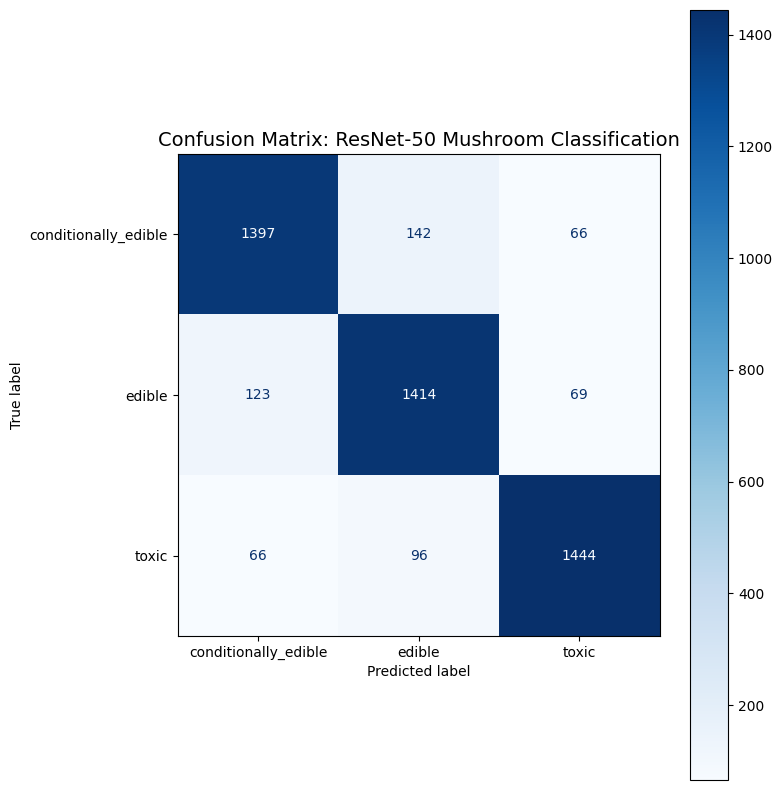

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix: ResNet-50 Mushroom Classification", fontsize=14)
plt.tight_layout()
plt.savefig(save_dir / "resnet50_robust1_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
clear_memory()